loading annotations into memory...
Done (t=0.75s)
creating index...
index created!


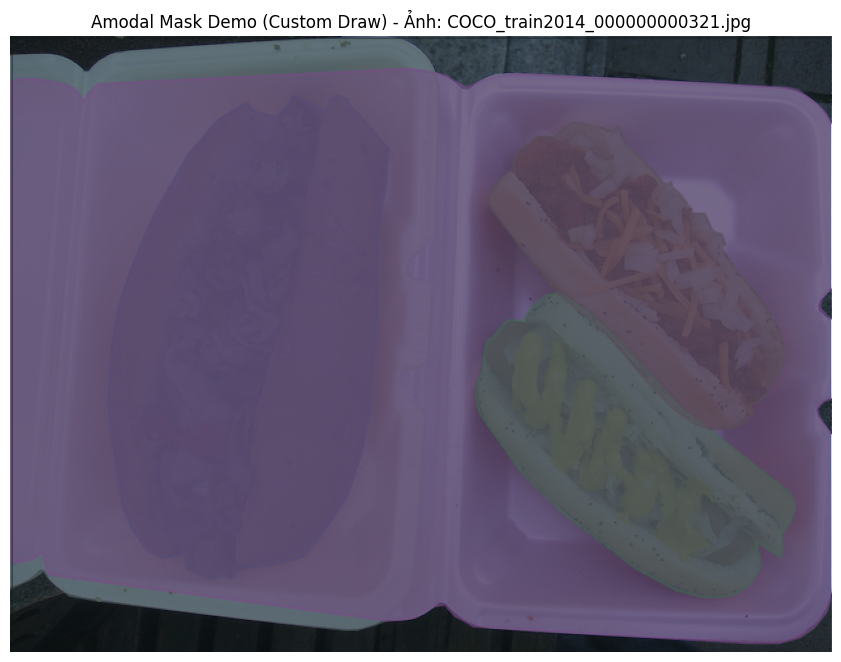

In [1]:
import os
import json
import cv2
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
import numpy as np

# 1. Khởi tạo đường dẫn đến file JSON và thư mục ảnh
data_dir = '../data'
ann_file = os.path.join(data_dir, 'annotations', 'COCO_amodal_train2014.json') # Thay bằng tên file JSON thật
img_dir = os.path.join(data_dir, 'train2014')

# 2. Load bộ dữ liệu COCOA
coco_amodal = COCO(ann_file)

# 3. BỎ QUA lọc category. Bốc thẳng bức ảnh ĐẦU TIÊN có chứa mask trong dataset
# imgToAnns lưu trữ mọi annotation, tụi mình lấy đại 1 cái ID ảnh ở vị trí số 0
img_id = list(coco_amodal.imgToAnns.keys())[0]

# Lấy thông tin bức ảnh đó
img_info = coco_amodal.loadImgs([img_id])[0] 

# Đọc ảnh gốc bằng OpenCV
img_path = os.path.join(img_dir, img_info['file_name'])
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 4. Lấy TẤT CẢ các nhãn (annotations) có trong bức ảnh đó
ann_ids = coco_amodal.getAnnIds(imgIds=[img_id])
anns = coco_amodal.loadAnns(ann_ids)

# 5. Vẽ (Visualize) lên màn hình
import matplotlib.patches as patches

import matplotlib.patches as patches

# 5. Tự tay "Mổ xẻ" và vẽ Amodal Mask lên màn hình
plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis('off')
plt.title(f"Amodal Mask Demo (Custom Draw) - Ảnh: {img_info['file_name']}")

ax = plt.gca()

# Lặp qua tất cả các nhãn (annotations) trong ảnh
for ann in anns:
    if 'regions' in ann:
        for region in ann['regions']:
            if 'segmentation' in region:
                segs = region['segmentation']
                
                # Kiểm tra cú lừa của dataset: Nếu nó là list 1 chiều chứa số, bọc nó lại thành mảng 2 chiều
                if isinstance(segs, list) and len(segs) > 0:
                    if isinstance(segs[0], (int, float)):
                        segs = [segs] # Bọc thêm 1 lớp ngoặc vuông
                        
                    # Tạo màu ngẫu nhiên
                    color = np.random.rand(3,) 
                    
                    for poly in segs:
                        # Bỏ qua nếu dữ liệu bị lỗi (một đa giác cần ít nhất 3 điểm, tức 6 con số)
                        if len(poly) < 6: 
                            continue
                            
                        # Giờ thì yên tâm cắt đôi mảng dẹt thành các cặp [x, y]
                        poly_2d = np.array(poly).reshape(-1, 2)
                        
                        # Vẽ miếng dán (patch) đè lên ảnh
                        polygon_patch = patches.Polygon(poly_2d, fill=True, alpha=0.5, color=color, linewidth=2)
                        ax.add_patch(polygon_patch)

plt.show()

Đang khởi tạo Dataset PyTorch...
Đang nạp file nhãn ../data/annotations/COCO_amodal_train2014.json vào bộ nhớ...
loading annotations into memory...
Done (t=0.76s)
creating index...
index created!
Hoàn tất! Đã bóc tách thành công 22163 vật thể độc lập.

--- KẾT QUẢ ÉP KIỂU TENSOR ---
Kích thước Image Tensor: torch.Size([4, 480, 640]) (C, H, W)
Kích thước Mask Tensor: torch.Size([480, 640]) (H, W)
Giá trị Mask nhỏ nhất: 0, Lớn nhất: 1 (Phải là 0 và 1)


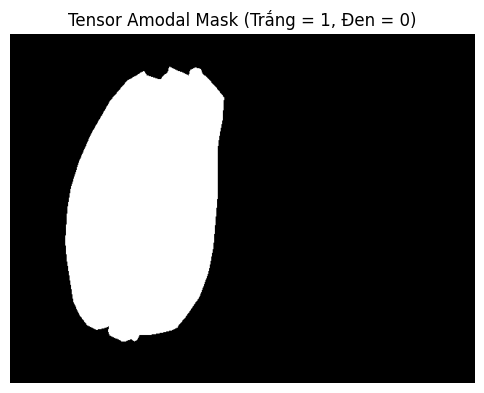

In [2]:
import sys
import matplotlib.pyplot as plt

# Khai báo đường dẫn để Notebook hiểu thư mục src
sys.path.append('../src')
from dataset import AmodalDataset

# 1. Khởi tạo Dataset (Cậu nhớ trỏ đúng đường dẫn của máy cậu nha)
img_dir = '../data/train2014'
ann_file = '../data/annotations/COCO_amodal_train2014.json'

print("Đang khởi tạo Dataset PyTorch...")
train_dataset = AmodalDataset(img_dir=img_dir, ann_file=ann_file)

# 2. Rút đại bức ảnh đầu tiên ra test thử
image_tensor, mask_tensor = train_dataset[0]

# 3. In ra kích thước (shape) để kiểm tra
print("\n--- KẾT QUẢ ÉP KIỂU TENSOR ---")
print(f"Kích thước Image Tensor: {image_tensor.shape} (C, H, W)")
print(f"Kích thước Mask Tensor: {mask_tensor.shape} (H, W)")
print(f"Giá trị Mask nhỏ nhất: {mask_tensor.min()}, Lớn nhất: {mask_tensor.max()} (Phải là 0 và 1)")

# 4. Vẽ thử cái Tensor Mask lên xem nó có đúng hình thù vật thể không
plt.figure(figsize=(6, 6))
plt.imshow(mask_tensor.numpy(), cmap='gray')
plt.title("Tensor Amodal Mask (Trắng = 1, Đen = 0)")
plt.axis('off')
plt.show()

c:\Users\THE NGUYEN\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Đang nạp file nhãn ../data/annotations/COCO_amodal_train2014.json vào bộ nhớ...
loading annotations into memory...
Done (t=0.77s)
creating index...
index created!
Hoàn tất! Đã bóc tách thành công 22163 vật thể độc lập.

--- KẾT QUẢ ĐÓNG GÓI MODEL HOÀN CHỈNH ---
Kích thước đút vào Model (4 Kênh): torch.Size([4, 4, 224, 224]) -> (Batch, 4 Channels, 224, 224)
Kích thước Nhãn dán Amodal Mask: torch.Size([4, 224, 224]) -> (Batch, 224, 224)


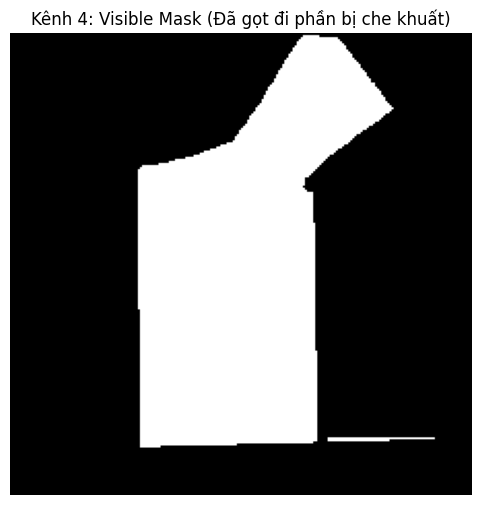

In [3]:
import albumentations as A
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 1. Định nghĩa phép biến đổi (Resize về 224x224 chuẩn Swin)
transform = A.Compose([
    A.Resize(224, 224),
])

# 2. Gắn transform vào Dataset
train_dataset = AmodalDataset(img_dir=img_dir, ann_file=ann_file, transform=transform)

# 3. Đưa vào Máy hút DataLoader (Bốc 4 ảnh cùng lúc)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

# 4. Hút thử 1 mẻ (1 batch)
inputs, targets = next(iter(train_loader))

print("\n--- KẾT QUẢ ĐÓNG GÓI MODEL HOÀN CHỈNH ---")
print(f"Kích thước đút vào Model (4 Kênh): {inputs.shape} -> (Batch, 4 Channels, 224, 224)")
print(f"Kích thước Nhãn dán Amodal Mask: {targets.shape} -> (Batch, 224, 224)")

# 5. MỞ HỘP KIỂM TRA: Lôi Kênh thứ 4 của bức ảnh đầu tiên ra vẽ thử!
plt.figure(figsize=(6, 6))
# inputs[0] là bức ảnh đầu tiên, lấy vị trí kênh số 3 (tức là kênh thứ 4)
plt.imshow(inputs[0, 3].numpy(), cmap='gray')
plt.title("Kênh 4: Visible Mask (Đã gọt đi phần bị che khuất)")
plt.axis('off')
plt.show()

In [4]:
import sys
import torch
sys.path.append('../src')
from model import AmodalSwinUNet

# Khởi tạo mô hình
model = AmodalSwinUNet()

# Tạo 1 batch giả: 4 bức ảnh, mỗi ảnh 4 kênh (3 RGB + 1 Visible Mask), kích thước 224x224
dummy_input = torch.randn(4, 4, 224, 224)

print(f"Kích thước đầu vào (Input): {dummy_input.shape}")

# Đút vào mô hình chạy thử
output = model(dummy_input)

print(f"Kích thước đầu ra (Output): {output.shape} -> (Phải là [4, 1, 256, 256])")

Đang khởi tạo bộ não Swin Transformer 4-Channel...
Kích thước đầu vào (Input): torch.Size([4, 4, 224, 224])
Kích thước đầu ra (Output): torch.Size([4, 1, 224, 224]) -> (Phải là [4, 1, 256, 256])


In [5]:
# Lôi đại vật thể đầu tiên trong Dataset ra khám nghiệm
ann_id, region_idx = train_dataset.instances[0]
region = train_dataset.coco.anns[ann_id]['regions'][region_idx]

# In ra xem nó có những thông tin gì
print("Các thông tin giấu trong 1 vật thể (region) gồm có:")
print(region.keys())

Các thông tin giấu trong 1 vật thể (region) gồm có:
dict_keys(['segmentation', 'name', 'area', 'isStuff', 'occlude_rate', 'order'])


In [6]:
# Lấy thử mẻ đầu tiên
inputs, targets = next(iter(train_loader))

print("\n--- KẾT QUẢ ĐÓNG GÓI MODEL HOÀN CHỈNH ---")
print(f"Kích thước đút vào Model (4 Kênh): {inputs.shape}")
print(f"Kích thước Nhãn dán Model tự học: {targets.shape}")


--- KẾT QUẢ ĐÓNG GÓI MODEL HOÀN CHỈNH ---
Kích thước đút vào Model (4 Kênh): torch.Size([4, 4, 224, 224])
Kích thước Nhãn dán Model tự học: torch.Size([4, 224, 224])
